# Customer Churn Prediction - Part 1: Data Cleaning and EDA
Simple beginner-level project using Telco Customer Churn dataset.

Steps:
1. Load data
2. Clean data
3. Basic EDA
4. Save cleaned data for Part 2 (model training)

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

In [2]:
data = pd.read_csv("churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape

(7043, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step 3: Clean the Data

First check for missing values.

In [6]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

`TotalCharges` should be a number but it is showing as object type. Let's fix that.

In [7]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"].isnull().sum()

np.int64(11)

In [8]:
# check the rows where TotalCharges is missing
data[data["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


These customers have tenure = 0, meaning they just joined and have not been billed yet. So we can fill missing TotalCharges with 0.

In [9]:
data["TotalCharges"] = data["TotalCharges"].fillna(0)
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

`customerID` column is not useful for prediction, so we can drop it.

In [10]:
data = data.drop("customerID", axis=1)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Check for duplicate rows.

In [11]:
data.duplicated().sum()

np.int64(22)

In [12]:
data = data.drop_duplicates()
data.shape

(7021, 20)

## Step 4: Basic EDA

In [13]:
data["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [14]:
data["Churn"].value_counts(normalize=True) * 100

Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64

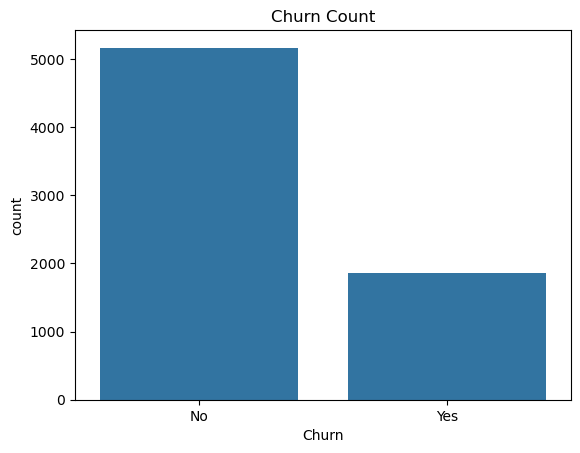

In [15]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Count")
plt.show()

### Step 4A: Numerical Columns EDA

Numerical columns in this dataset: `tenure`, `MonthlyCharges`, `TotalCharges`.
Each one is plotted separately below.

**tenure**

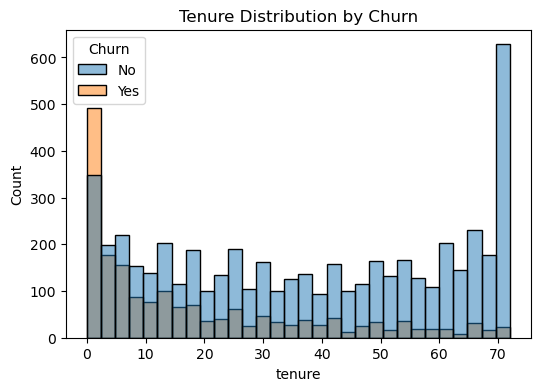

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x="tenure", hue="Churn", bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

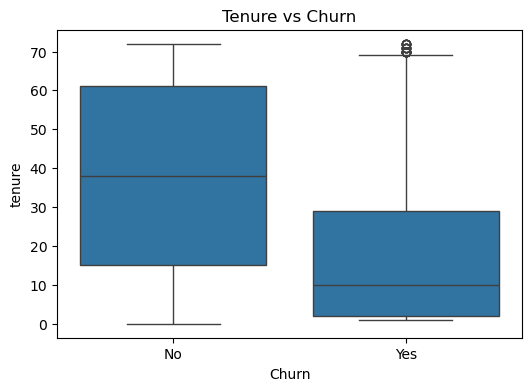

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=data)
plt.title("Tenure vs Churn")
plt.show()

**MonthlyCharges**

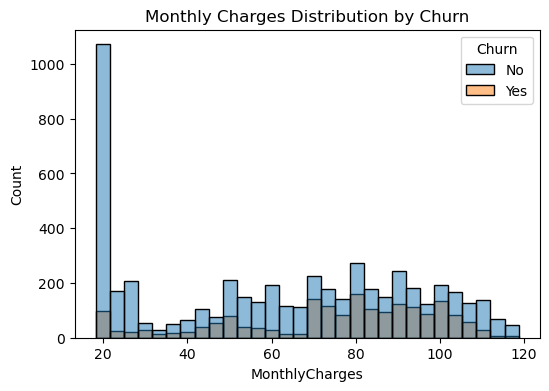

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x="MonthlyCharges", hue="Churn", bins=30)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

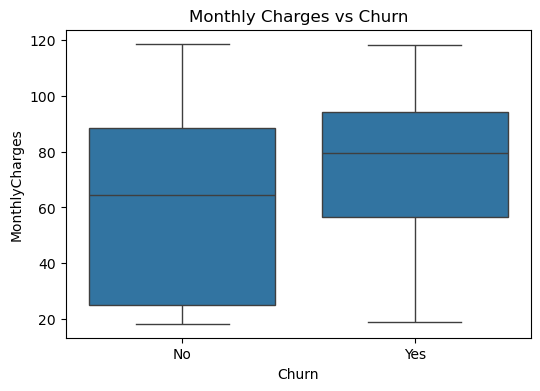

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

**TotalCharges**

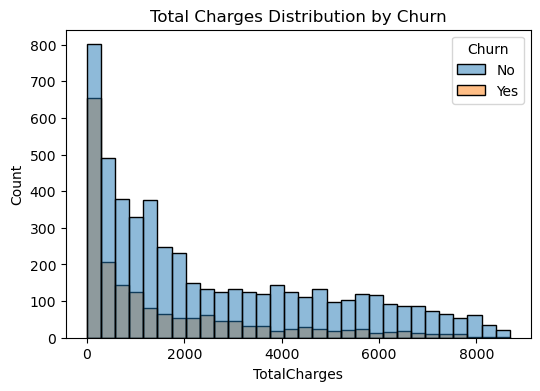

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x="TotalCharges", hue="Churn", bins=30)
plt.title("Total Charges Distribution by Churn")
plt.show()

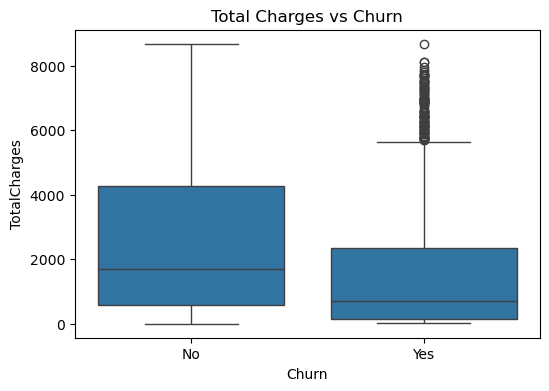

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="TotalCharges", data=data)
plt.title("Total Charges vs Churn")
plt.show()

Correlation between the numerical columns.

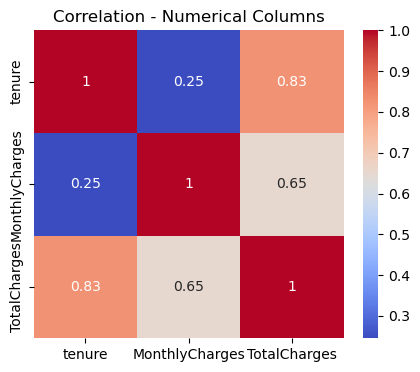

In [22]:
plt.figure(figsize=(5,4))
sns.heatmap(data[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation - Numerical Columns")
plt.show()

### Step 4B: Categorical Columns EDA

Each categorical column is plotted separately below (churn count split by category).

**gender**

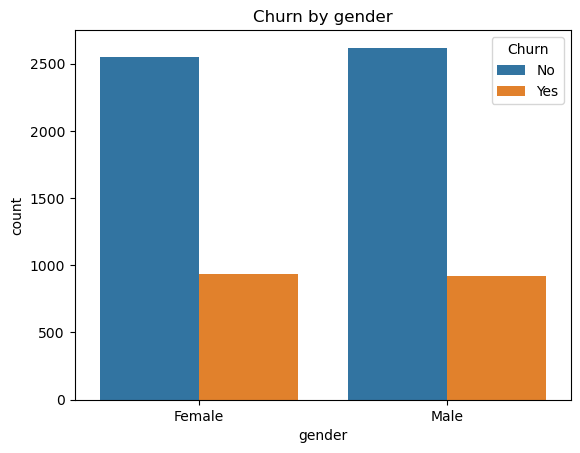

In [23]:
sns.countplot(x="gender", hue="Churn", data=data)
plt.title("Churn by gender")
plt.show()

**SeniorCitizen**

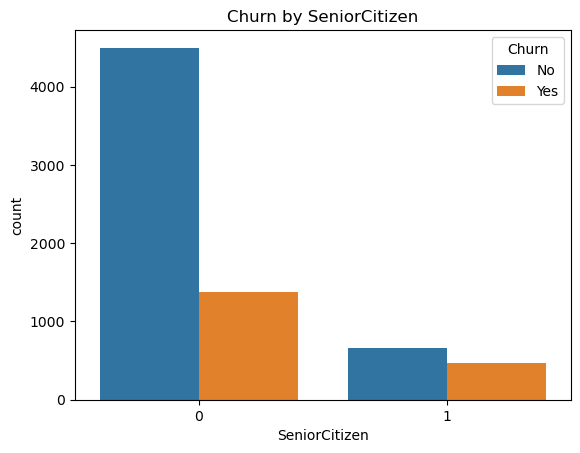

In [24]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=data)
plt.title("Churn by SeniorCitizen")
plt.show()

**Partner**

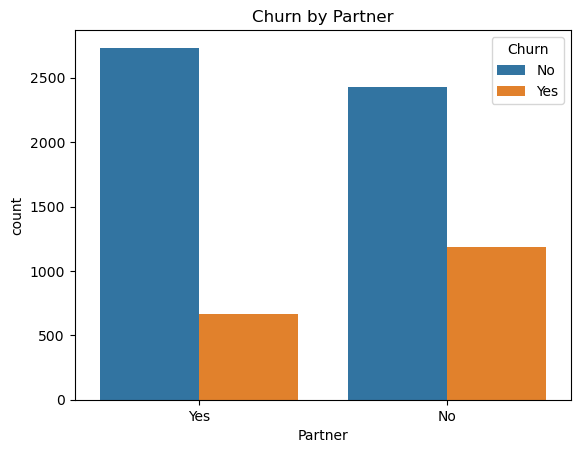

In [25]:
sns.countplot(x="Partner", hue="Churn", data=data)
plt.title("Churn by Partner")
plt.show()

**Dependents**

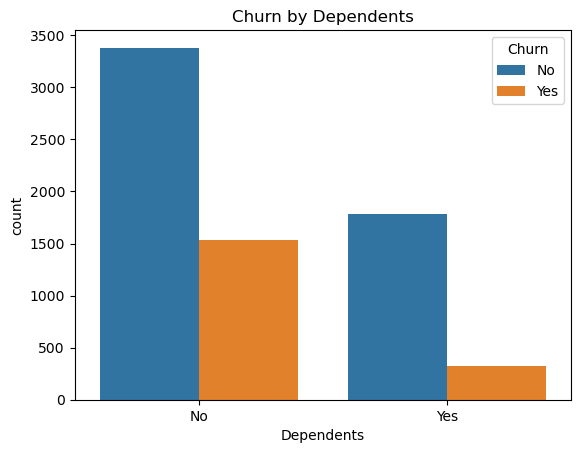

In [26]:
sns.countplot(x="Dependents", hue="Churn", data=data)
plt.title("Churn by Dependents")
plt.show()

**PhoneService**

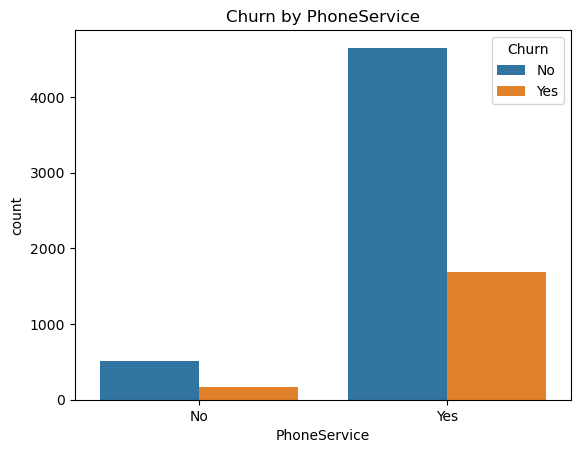

In [27]:
sns.countplot(x="PhoneService", hue="Churn", data=data)
plt.title("Churn by PhoneService")
plt.show()

**MultipleLines**

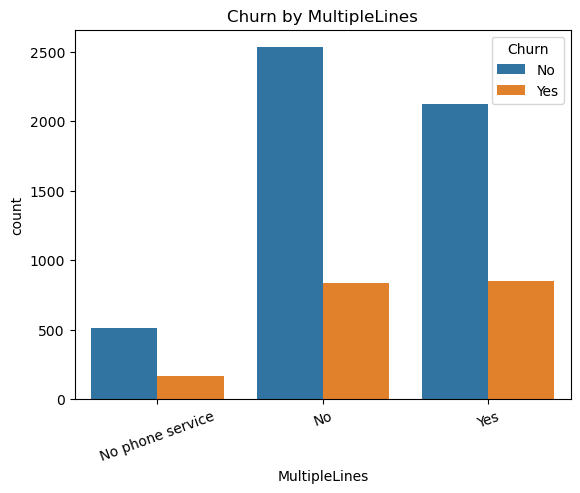

In [28]:
sns.countplot(x="MultipleLines", hue="Churn", data=data)
plt.title("Churn by MultipleLines")
plt.xticks(rotation=20)
plt.show()

**InternetService**

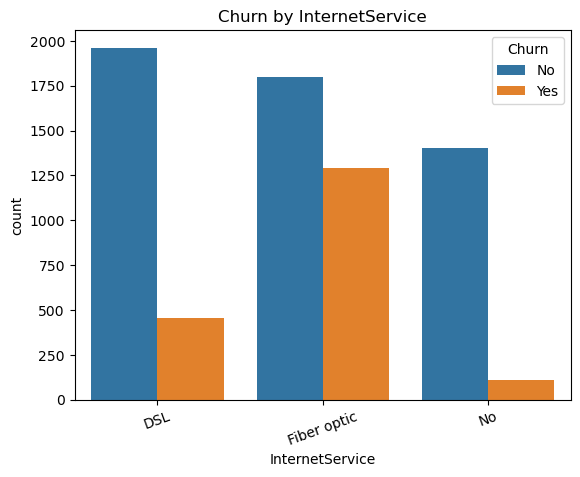

In [29]:
sns.countplot(x="InternetService", hue="Churn", data=data)
plt.title("Churn by InternetService")
plt.xticks(rotation=20)
plt.show()

**OnlineSecurity**

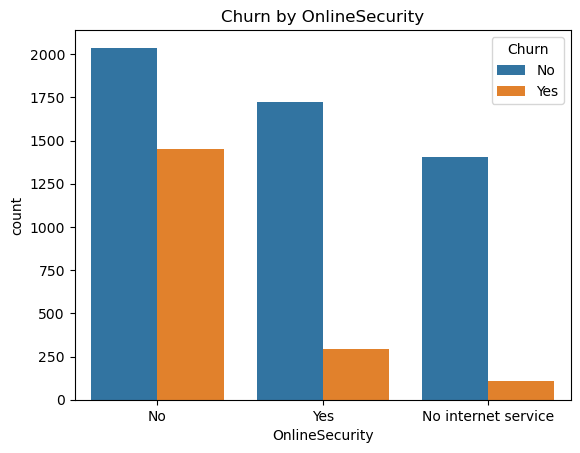

In [30]:
sns.countplot(x="OnlineSecurity", hue="Churn", data=data)
plt.title("Churn by OnlineSecurity")
plt.show()

**OnlineBackup**

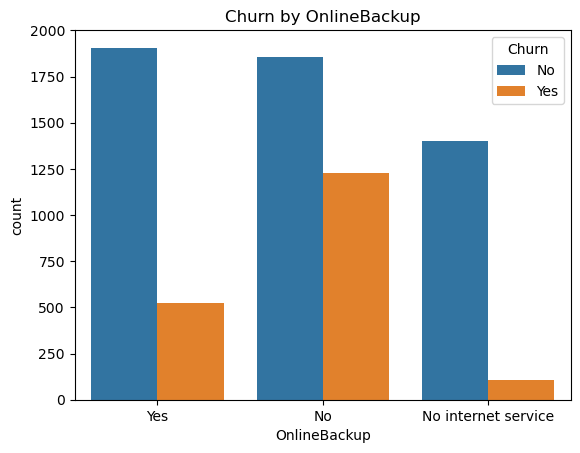

In [31]:
sns.countplot(x="OnlineBackup", hue="Churn", data=data)
plt.title("Churn by OnlineBackup")
plt.show()

**DeviceProtection**

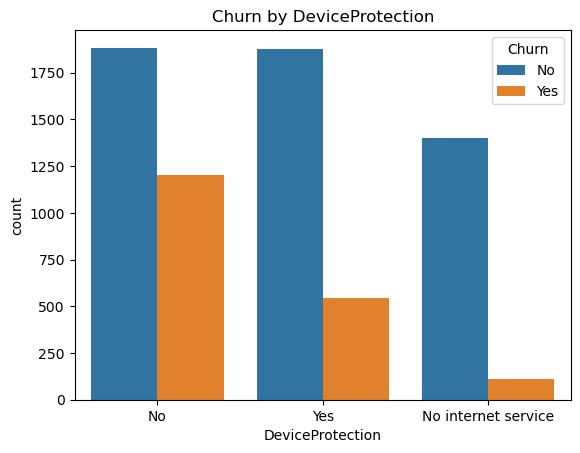

In [32]:
sns.countplot(x="DeviceProtection", hue="Churn", data=data)
plt.title("Churn by DeviceProtection")
plt.show()

**TechSupport**

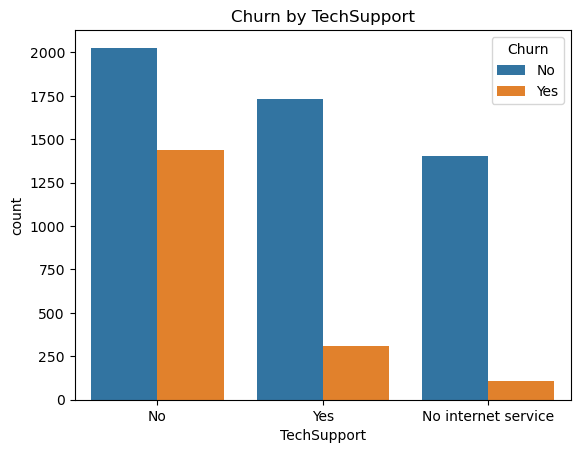

In [33]:
sns.countplot(x="TechSupport", hue="Churn", data=data)
plt.title("Churn by TechSupport")
plt.show()

**StreamingTV**

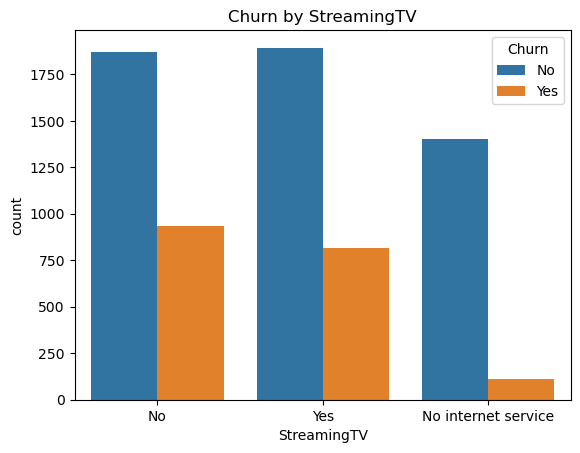

In [34]:
sns.countplot(x="StreamingTV", hue="Churn", data=data)
plt.title("Churn by StreamingTV")
plt.show()

**StreamingMovies**

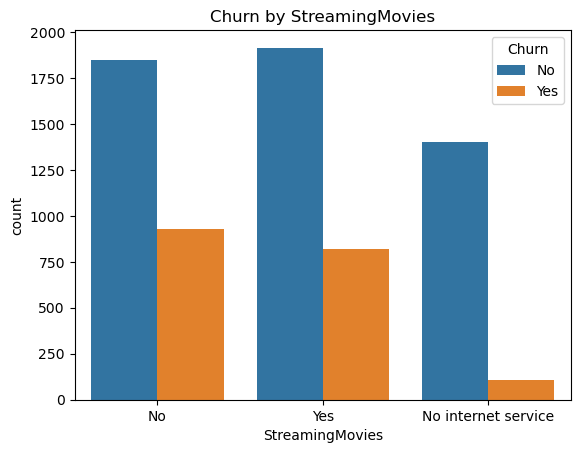

In [35]:
sns.countplot(x="StreamingMovies", hue="Churn", data=data)
plt.title("Churn by StreamingMovies")
plt.show()

**Contract**

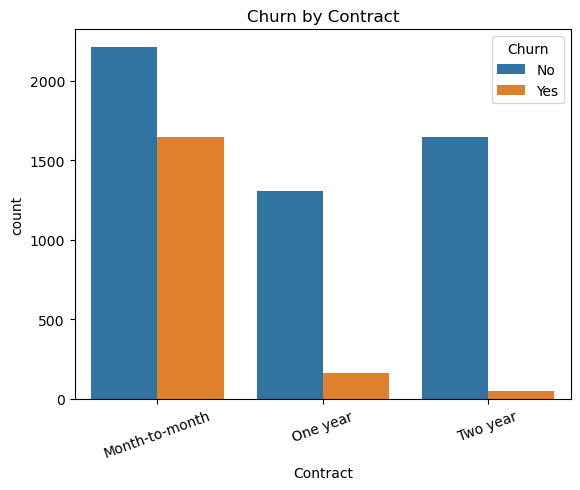

In [36]:
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Churn by Contract")
plt.xticks(rotation=20)
plt.show()

**PaperlessBilling**

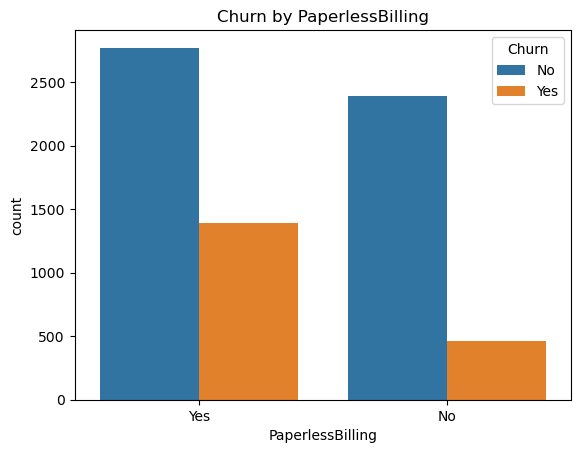

In [37]:
sns.countplot(x="PaperlessBilling", hue="Churn", data=data)
plt.title("Churn by PaperlessBilling")
plt.show()

**PaymentMethod**

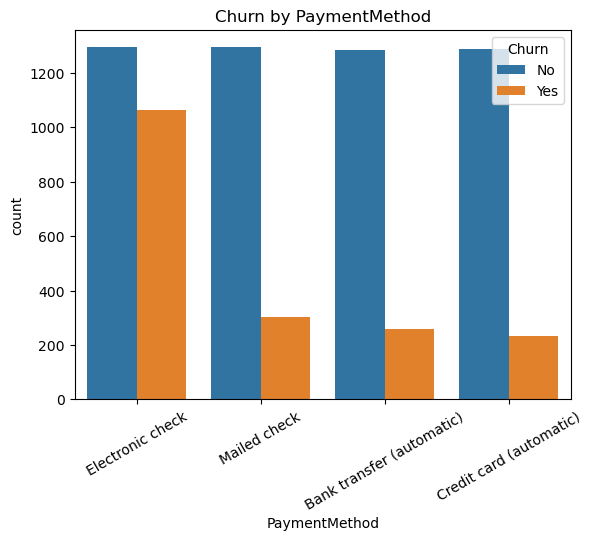

In [38]:
sns.countplot(x="PaymentMethod", hue="Churn", data=data)
plt.title("Churn by PaymentMethod")
plt.xticks(rotation=30)
plt.show()

## Step 5: Save Cleaned Data

This cleaned file will be used in Part 2 (model training), so we don't have to repeat the cleaning steps again.

In [39]:
data.to_csv("churn_cleaned.csv", index=False)
print("Saved churn_cleaned.csv")

Saved churn_cleaned.csv


## Key Insights

### Categorical Features vs Churn

| Feature | Category | Churn Rate |
|---|---|---|
| gender | Female | 26.84% |
| gender | Male | 26.07% |
| SeniorCitizen | Yes | 41.63% |
| SeniorCitizen | No | 23.50% |
| Partner | No | 32.83% |
| Partner | Yes | 19.66% |
| Dependents | No | 31.17% |
| Dependents | Yes | 15.45% |
| PhoneService | Yes | 26.61% |
| PhoneService | No | 24.93% |
| MultipleLines | Yes | 28.61% |
| MultipleLines | No phone service | 24.93% |
| MultipleLines | No | 24.85% |
| InternetService | Fiber optic | 41.78% |
| InternetService | DSL | 18.89% |
| InternetService | No | 7.21% |
| OnlineSecurity | No | 41.63% |
| OnlineSecurity | Yes | 14.61% |
| OnlineSecurity | No internet service | 7.21% |
| OnlineBackup | No | 39.77% |
| OnlineBackup | Yes | 21.53% |
| OnlineBackup | No internet service | 7.21% |
| DeviceProtection | No | 38.97% |
| DeviceProtection | Yes | 22.50% |
| DeviceProtection | No internet service | 7.21% |
| TechSupport | No | 41.50% |
| TechSupport | Yes | 15.17% |
| TechSupport | No internet service | 7.21% |
| StreamingTV | No | 33.33% |
| StreamingTV | Yes | 30.07% |
| StreamingTV | No internet service | 7.21% |
| StreamingMovies | No | 33.49% |
| StreamingMovies | Yes | 29.94% |
| StreamingMovies | No internet service | 7.21% |
| Contract | Month-to-month | 42.64% |
| Contract | One year | 11.27% |
| Contract | Two year | 2.83% |
| PaperlessBilling | Yes | 33.43% |
| PaperlessBilling | No | 16.29% |
| PaymentMethod | Electronic check | 45.15% |
| PaymentMethod | Mailed check | 18.92% |
| PaymentMethod | Bank transfer (automatic) | 16.71% |
| PaymentMethod | Credit card (automatic) | 15.24% |

### Numerical Features vs Churn

| Feature | Avg. Value (Churn = Yes) | Avg. Value (Churn = No) | Insight |
|---|---|---|---|
| tenure | 18.1 months | 37.6 months | Churned customers leave roughly twice as early |
| MonthlyCharges | ₹74.60 | ₹61.34 | Churned customers pay more per month on average |
| TotalCharges | ₹1,541.38 | ₹2,554.81 | Churned customers have lower lifetime value (shorter tenure despite higher monthly rate) |

### Overall Churn Rate

| Metric | Value |
|---|---|
| Total customers | 7,021 |
| Churned customers | 1,857 |
| Retained customers | 5,164 |
| **Overall churn rate** | **26.45%** |

**Strongest churn driver:** Contract type (Month-to-month = 42.64% vs Two-year = 2.83%)
**Weakest churn driver:** Gender (26.84% vs 26.07% — almost no difference)
